# **MODELO 1: CLASIFICACIÓN: APROBADA O NEGADA**

Este notebook construye y evalúa modelos de clasificación para predecir si un aspirante será aprobado o negado en el programa Becas Talento. Se utilizan los datos procesados y anonimizados (df_model) preparados en el EDA.

#Carga y preparación del dataset
Se carga el df_model específico para esta tarea, se seleccionan las columnas relevantes y se realiza la codificación de variables categóricas, dejando el conjunto listo para el entrenamiento de modelos.

In [ ]:
import pandas as pd

file_path = "/content/df_model_Aprob_Neg.xlsx"

# Cargar el dataset
df = pd.read_excel(file_path)

# Vista rápida
print("Dimensiones del dataset:", df.shape)
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum())

# Balance de clases en la variable objetivo
print("\nDistribución de la variable 'Resultado Final':")
print(df["Resultado Final"].value_counts(normalize=True) * 100)


Dimensiones del dataset: (5890, 18)

Columnas disponibles:
['ID_anon', 'Resultado Final', 'puntos_academicos_int', 'Pregrado al que aspiras', 'Estado de matricula', '% beca talento final aprobada', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse', 'Sexo biológico', 'Dpto de Residencia']

Valores nulos por columna:
ID_anon                          0
Resultado Final                  0
puntos_academicos_int            0
Pregrado al que aspiras          0
Estado de matricula              0
% beca talento final aprobada    0
Entrevista                       0
paso_entrevista                  0
Ensayo                           0
paso_ensayo                      0
dependencia_economica            0
Padres_profesionales             0
log_ingresos_padres              0
puntos_estrato                   0
analisis_economico               0
Edad al postulars

# División de datos en entrenamiento y prueba

Se separan los datos en conjuntos de entrenamiento y prueba utilizando una partición estratificada para conservar la proporción original de clases (Aprobada/Negada).

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Eliminar columnas no predictoras
df_model = df.drop(columns=["ID_anon","Estado de matricula", "% beca talento final aprobada"])

# Variable objetivo
y = df_model["Resultado Final"].map({"Aprobada": 1, "Negada": 0})
X = df_model.drop(columns=["Resultado Final"])

In [ ]:
# Identificar tipos de variables
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Variables categóricas:", cat_cols)
print("Variables numéricas:", num_cols)

Variables categóricas: ['Pregrado al que aspiras', 'Sexo biológico', 'Dpto de Residencia']
Variables numéricas: ['puntos_academicos_int', 'Entrevista', 'paso_entrevista', 'Ensayo', 'paso_ensayo', 'dependencia_economica', 'Padres_profesionales', 'log_ingresos_padres', 'puntos_estrato', 'analisis_economico', 'Edad al postularse']


In [ ]:
# OneHotEncoding (para categóricas)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("\nDimensiones después de OneHotEncoding:", X_encoded.shape)


Dimensiones después de OneHotEncoding: (5890, 87)


In [ ]:
#División train-test (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTamaños de los conjuntos:")
print("Entrenamiento:", X_train.shape, "Prueba:", X_test.shape)
print("\nDistribución de clases (train):")
print(y_train.value_counts(normalize=True))



Tamaños de los conjuntos:
Entrenamiento: (4123, 87) Prueba: (1767, 87)

Distribución de clases (train):
Resultado Final
0    0.641523
1    0.358477
Name: proportion, dtype: float64


# Árbol de decisiones (modelo base)

Se entrena un árbol de decisión inicial para establecer un punto de referencia. Aquí se observan sus métricas, matriz de confusión e importancia de variables

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Definir y entrenar el modelo
dt = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    random_state=42
)

dt.fit(X_train, y_train)

# Predicciones
y_pred = dt.predict(X_test)

#  Métricas principales
print("Árbol de Decisión")
print(classification_report(y_test, y_pred, target_names=["Negada", "Aprobada"]))

f1 = f1_score(y_test, y_pred)
print(f"\nF1-Score global: {f1:.3f}")#



Árbol de Decisión
              precision    recall  f1-score   support

      Negada       0.90      0.90      0.90      1134
    Aprobada       0.83      0.83      0.83       633

    accuracy                           0.88      1767
   macro avg       0.87      0.87      0.87      1767
weighted avg       0.88      0.88      0.88      1767


F1-Score global: 0.827


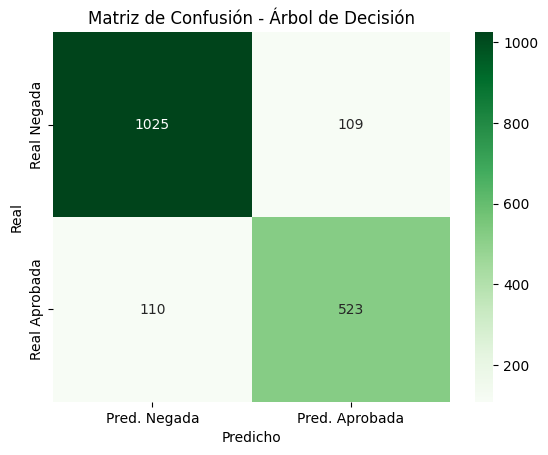

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred. Negada", "Pred. Aprobada"],
            yticklabels=["Real Negada", "Real Aprobada"])
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()



/tmp/ipython-input-2872081260.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vars.values, y=top_vars.index, palette="viridis")


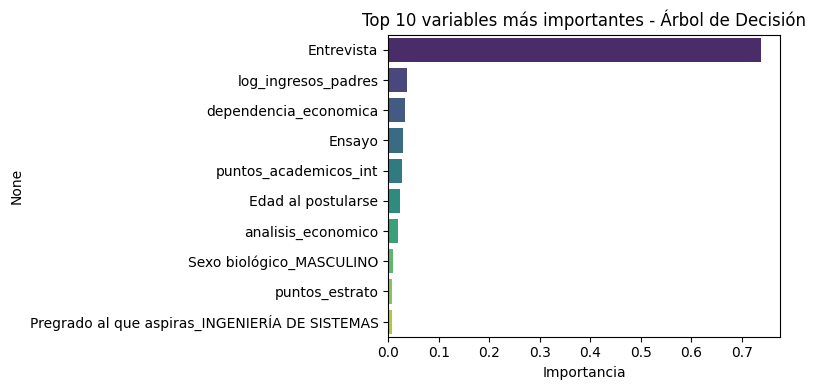

In [ ]:
# Importancia de variables
importances = pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars = importances.head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top_vars.values, y=top_vars.index, palette="viridis")
plt.title("Top 10 variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

# 2. Random Forest (modelo base)

Se implementa un Random Forest para mejorar estabilidad y desempeño respecto al árbol simple. Se revisan métricas, matriz de confusión y top de variables relevantes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definir y entrenar el modelo
rf = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predicción (clase dura) y probas
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


In [ ]:
# Métricas
print("Random Forest")
print(classification_report(y_test, y_pred, target_names=["Negada", "Aprobada"]))
print(f"F1-Score global: {f1_score(y_test, y_pred):.3f}")

Random Forest
              precision    recall  f1-score   support

      Negada       0.94      0.89      0.92      1134
    Aprobada       0.83      0.91      0.86       633

    accuracy                           0.90      1767
   macro avg       0.89      0.90      0.89      1767
weighted avg       0.90      0.90      0.90      1767

F1-Score global: 0.864


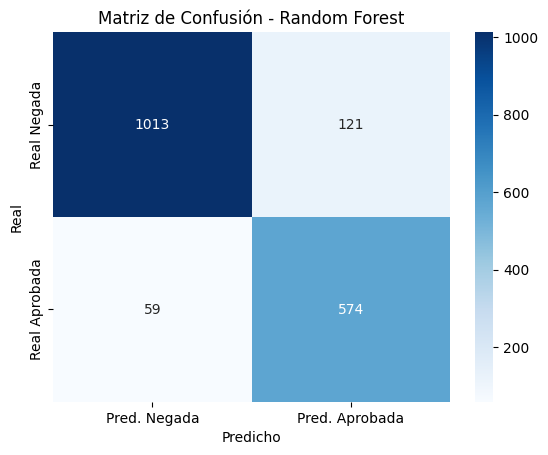

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred. Negada", "Pred. Aprobada"],
            yticklabels=["Real Negada", "Real Aprobada"])
plt.title("Matriz de Confusión - Random Forest")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


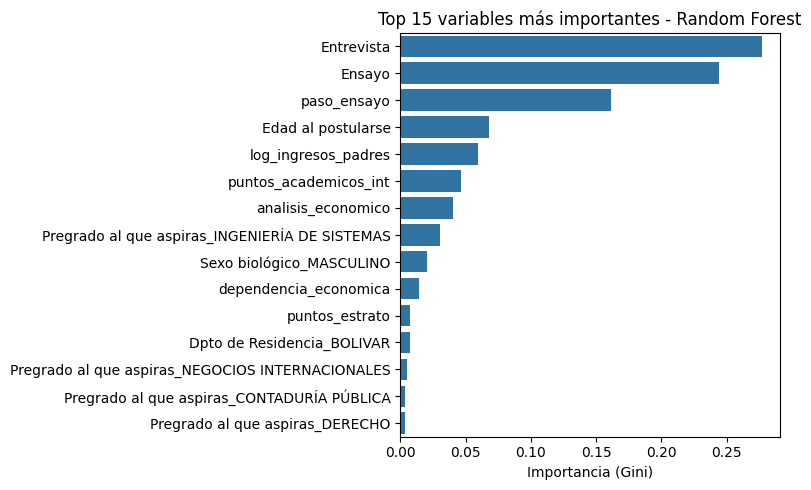

In [ ]:
# Importancia de variables
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars = importances.head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_vars.values, y=top_vars.index)
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia (Gini)")
plt.ylabel("")
plt.tight_layout()
plt.show()


# XGBOOST (modelo base)

Se entrena un modelo XGBoost aprovechando su capacidad para manejar desbalance y capturar relaciones no lineales. Se evalúan sus métricas y la importancia de características.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calcular balance de clases
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Relación Negada/Aprobada = {ratio:.2f}")

# Definir el modelo
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción y evaluación
y_pred = xgb.predict(X_test)
print("XGBoost")
print(classification_report(y_test, y_pred, target_names=["Negada", "Aprobada"]))
print(f"F1-Score global: {f1_score(y_test, y_pred):.3f}")





Relación Negada/Aprobada = 1.79
XGBoost
              precision    recall  f1-score   support

      Negada       0.95      0.92      0.93      1134
    Aprobada       0.86      0.91      0.88       633

    accuracy                           0.91      1767
   macro avg       0.90      0.91      0.91      1767
weighted avg       0.91      0.91      0.91      1767

F1-Score global: 0.880


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:25:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


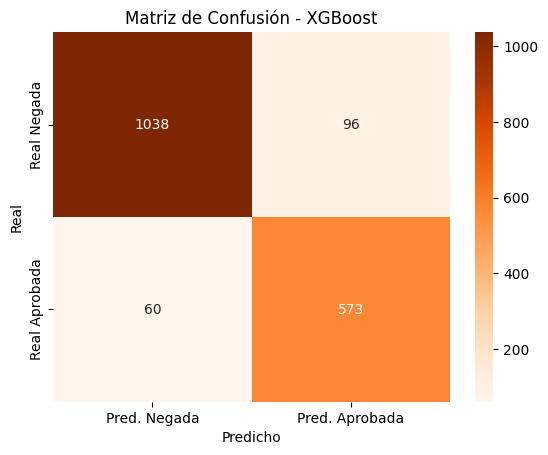

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Pred. Negada", "Pred. Aprobada"],
            yticklabels=["Real Negada", "Real Aprobada"])
plt.title("Matriz de Confusión - XGBoost")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()

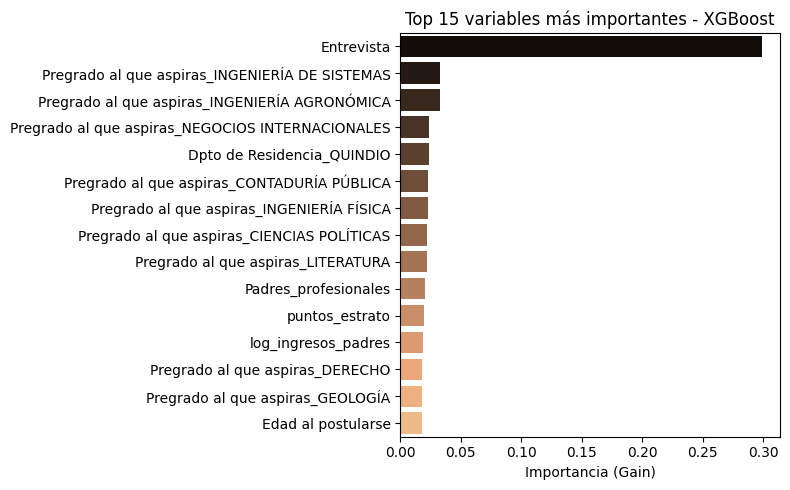

In [ ]:

# Importancia de variables
importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_vars = importances.head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_vars.values, y=top_vars.index, hue=top_vars.index, palette="copper", legend=False)
plt.title("Top 15 variables más importantes - XGBoost")
plt.xlabel("Importancia (Gain)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Regresión Logistica (modelo base)

Se utiliza una regresión logística con balanceo de clases para comparar su desempeño frente a los modelos basados en árboles. Se revisan métricas, precisión y recall para cada clase.

Regresión Logística BASE
              precision    recall  f1-score   support

      Negada       0.97      0.88      0.92      1134
    Aprobada       0.82      0.95      0.88       633

    accuracy                           0.91      1767
   macro avg       0.90      0.92      0.90      1767
weighted avg       0.92      0.91      0.91      1767

F1-Score global: 0.881


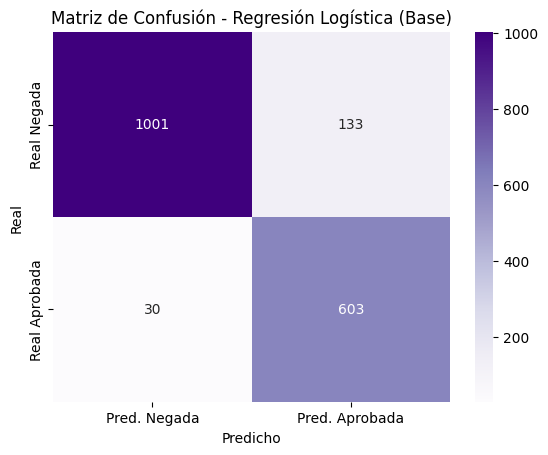

In [ ]:
# 1. Regresión Logística BASE

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

log_reg = LogisticRegression(
    class_weight="balanced",   # por el desbalance
    max_iter=1000,
    n_jobs=-1,
    solver="lbfgs"
)

# Entrenamiento
log_reg.fit(X_train, y_train)

# Predicciones
y_pred_log = log_reg.predict(X_test)

print("Regresión Logística BASE")
print(classification_report(y_test, y_pred_log, target_names=["Negada", "Aprobada"]))

f1_log = f1_score(y_test, y_pred_log)
print(f"F1-Score global: {f1_log:.3f}")

# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred. Negada", "Pred. Aprobada"],
            yticklabels=["Real Negada", "Real Aprobada"])
plt.title("Matriz de Confusión - Regresión Logística (Base)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


# Comparación de modelos

Se consolidan las métricas de todos los modelos (Precisión, Recall, F1 y Accuracy) para identificar cuál presenta mejor desempeño en la clasificación binaria del resultado final.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicciones de cada modelo
models = {
    "Árbol de Decisión": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "Regresión Logística": log_reg
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Modelo": name,
        "Precisión": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Acurracy": model.score(X_test, y_test),
        "ROC_AUC": roc_curve(y_test, y_pred_log, pos_label=1)[0][1]
    })

# Crear DataFrame comparativo
df_results = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
display(df_results)


,Modelo,Precisión,Recall,F1-Score,Acurracy,ROC_AUC
3,Regresión Logística,0.819293,0.952607,0.880935,0.907753,0.117284
2,XGBoost,0.856502,0.905213,0.880184,0.911715,0.117284
1,Random Forest,0.825899,0.906793,0.864458,0.898132,0.117284
0,Árbol de Decisión,0.827532,0.826224,0.826877,0.876061,0.117284


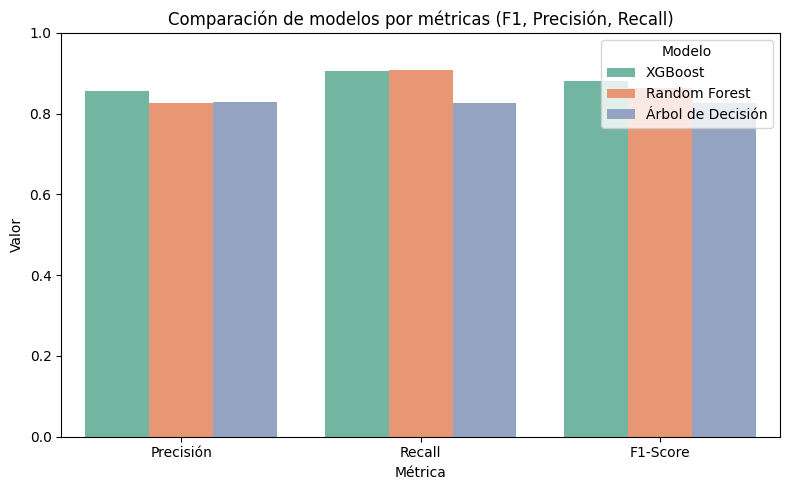

In [ ]:
# Visualización comparativa
plt.figure(figsize=(8,5))
sns.barplot(data=df_results.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor"),
            x="Métrica", y="Valor", hue="Modelo", palette="Set2")
plt.title("Comparación de modelos por métricas (F1, Precisión, Recall)")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

In [ ]:
# Mejor modelo según F1
best_model = df_results.iloc[0]
print(f"Mejor modelo: {best_model['Modelo']} (F1={best_model['F1-Score']:.3f})")


Mejor modelo: XGBoost (F1=0.880)


# Aplicación de técnicas de optimización de los modelos

# SMOTE para manejo del desbalance

Se aplica la técnica SMOTE para equilibrar la clase minoritaria y se entrena de nuevo el modelo de árbol. Se comparan resultados con y sin SMOTE para evaluar su impacto real.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Distribución original:")
print(y_train.value_counts())

print("\nDistribución balanceada con SMOTE:")
print(y_train_sm.value_counts())


Distribución original:
Resultado Final
0    2645
1    1478
Name: count, dtype: int64

Distribución balanceada con SMOTE:
Resultado Final
0    2645
1    2645
Name: count, dtype: int64


In [ ]:
dt_smote = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=None,
    random_state=42
)

dt_smote.fit(X_train_sm, y_train_sm)

# Predicciones sobre el test (sin SMOTE)
y_pred_smote = dt_smote.predict(X_test)

print("Árbol de Decisión con SMOTE")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote, target_names=["Negada", "Aprobada"]))

f1 = f1_score(y_test, y_pred_smote)
print(f"\nF1-Score con SMOTE: {f1:.3f}")





Árbol de Decisión con SMOTE
[[1000  134]
 [ 107  526]]
              precision    recall  f1-score   support

      Negada       0.90      0.88      0.89      1134
    Aprobada       0.80      0.83      0.81       633

    accuracy                           0.86      1767
   macro avg       0.85      0.86      0.85      1767
weighted avg       0.87      0.86      0.86      1767


F1-Score con SMOTE: 0.814


# Comparación de Modelos con y sin SMOTE


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pl

In [ ]:
y_pred_base  = dt.predict(X_test)        # Árbol original
y_pred_smote = dt_smote.predict(X_test)  # Árbol entrenado con SMOTE

In [ ]:
print("ÁRBOL DE DECISIÓN - SIN SMOTE")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base, target_names=["Negada", "Aprobada"]))

f1_base = f1_score(y_test, y_pred_base)
print(f"F1-Score SIN SMOTE: {f1_base:.3f}")

ÁRBOL DE DECISIÓN - SIN SMOTE
Matriz de confusión:
[[1025  109]
 [ 110  523]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Negada       0.90      0.90      0.90      1134
    Aprobada       0.83      0.83      0.83       633

    accuracy                           0.88      1767
   macro avg       0.87      0.87      0.87      1767
weighted avg       0.88      0.88      0.88      1767

F1-Score SIN SMOTE: 0.827


In [ ]:
print("ÁRBOL DE DECISIÓN - CON SMOTE ")
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_smote))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_smote, target_names=["Negada", "Aprobada"]))

f1_smote = f1_score(y_test, y_pred_smote)
print(f"F1-Score CON SMOTE: {f1_smote:.3f}")

ÁRBOL DE DECISIÓN - CON SMOTE 
Matriz de confusión:
[[1000  134]
 [ 107  526]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Negada       0.90      0.88      0.89      1134
    Aprobada       0.80      0.83      0.81       633

    accuracy                           0.86      1767
   macro avg       0.85      0.86      0.85      1767
weighted avg       0.87      0.86      0.86      1767

F1-Score CON SMOTE: 0.814


COMPARATIVO
            Modelo  F1-Score
0  Árbol sin SMOTE  0.826877
1  Árbol con SMOTE  0.813612


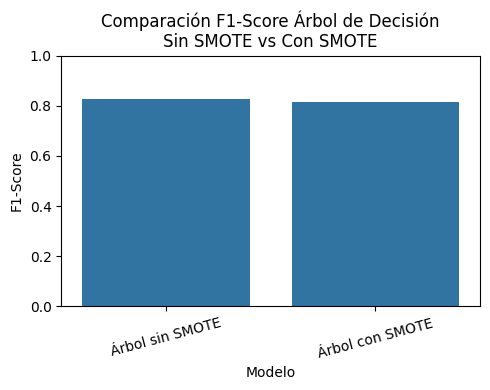

In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["Árbol sin SMOTE", "Árbol con SMOTE"],
    "F1-Score": [f1_base, f1_smote]
})

print("COMPARATIVO")
print(comparacion)

#Comparación visual
plt.figure(figsize=(5,4))
sns.barplot(data=comparacion, x="Modelo", y="F1-Score")
plt.title("Comparación F1-Score Árbol de Decisión\nSin SMOTE vs Con SMOTE")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

La optimización con SMOTE no fue eficiente considerando que el F1 Score disminuyó. Esto se debe a que la asignación de becas por naturaleza es un problema con desbalance de clases. Considerando lo anterior, se selecciona el modelo antes del smote para compararlo con Random Forest y XGBoots

# Optimización con GridSearch

Se realiza búsqueda de hiperparámetros (GridSearchCV) todos los modelos con el fin de mejorar el desempeño del modelo mediante ajustes en profundidad, nodos y criterios de división.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Árboles de decisión

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)


In [ ]:
param_grid_dt = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Mejores parámetros (Árbol de Decisión):")
print(grid_dt.best_params_)
print(f"F1 promedio CV: {grid_dt.best_score_:.4f}")


Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejores parámetros (Árbol de Decisión):
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 20}
F1 promedio CV: 0.8736


In [ ]:
best_dt = grid_dt.best_estimator_

y_pred_dt_best = best_dt.predict(X_test)
f1_dt_best = f1_score(y_test, y_pred_dt_best)

print("\nÁrbol optimizado (GridSearch)")
print(classification_report(y_test, y_pred_dt_best, target_names=["Negada", "Aprobada"]))
print(f"F1-Score test optimizado: {f1_dt_best:.3f}")



Árbol optimizado (GridSearch)
              precision    recall  f1-score   support

      Negada       0.97      0.89      0.93      1134
    Aprobada       0.83      0.95      0.88       633

    accuracy                           0.91      1767
   macro avg       0.90      0.92      0.91      1767
weighted avg       0.92      0.91      0.91      1767

F1-Score test optimizado: 0.884


In [ ]:
df_comp_dt = pd.DataFrame({
    "Modelo": ["Árbol base", "Árbol GridSearch"],
    "F1_test": [f1, f1_dt_best]
})

df_comp_dt


,Modelo,F1_test
0,Árbol base,0.813612
1,Árbol GridSearch,0.883652


#Random Forest

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred_base = rf.predict(X_test)
f1_base = f1_score(y_test, y_pred_base)

print("Random Forest BASE")
print(classification_report(y_test, y_pred_base, target_names=["Negada", "Aprobada"]))
print(f"F1-Score test (base): {f1_base:.3f}")

Random Forest BASE
              precision    recall  f1-score   support

      Negada       0.94      0.89      0.92      1134
    Aprobada       0.83      0.91      0.86       633

    accuracy                           0.90      1767
   macro avg       0.89      0.90      0.89      1767
weighted avg       0.90      0.90      0.90      1767

F1-Score test (base): 0.864


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Modelo "base" para el grid (sin fijar hiperparámetros muy específicos)
rf_base = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

# Espacio de búsqueda
param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros encontrados (CV):")
print(grid_rf.best_params_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores parámetros encontrados (CV):
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)
f1_best = f1_score(y_test, y_pred_best)

print("\nRandom Forest Optimizado (GridSearch)")
print(classification_report(y_test, y_pred_best, target_names=["Negada", "Aprobada"]))
print(f"F1-Score test (optimizado): {f1_best:.3f}")



Random Forest Optimizado (GridSearch)
              precision    recall  f1-score   support

      Negada       0.97      0.90      0.93      1134
    Aprobada       0.83      0.94      0.89       633

    accuracy                           0.91      1767
   macro avg       0.90      0.92      0.91      1767
weighted avg       0.92      0.91      0.91      1767

F1-Score test (optimizado): 0.885


In [ ]:
import pandas as pd

df_comp_rf = pd.DataFrame({
    "Modelo": ["RF base", "RF GridSearch"],
    "F1_test": [f1_base, f1_best]
})

display(df_comp_rf)


,Modelo,F1_test
0,RF base,0.864458
1,RF GridSearch,0.885100


# XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)

xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
f1_xgb_base = f1_score(y_test, y_pred_xgb_base)
print(f"F1-Score XGBoost base: {f1_xgb_base:.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:38:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-Score XGBoost base: 0.883


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid_xgb = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],

}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric="logloss",
        random_state=42,
        use_label_encoder=False
    ),
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:43:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [200, 300, 400],
                         'subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [ ]:
print("Mejores parámetros encontrados (XGBoost):")
print(grid_xgb.best_params_)
print(f"F1 promedio CV: {grid_xgb.best_score_:.4f}")


Mejores parámetros encontrados (XGBoost):
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
F1 promedio CV: 0.8812


In [ ]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_best = best_xgb.predict(X_test)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best)

print("\nXGBoost optimizado (GridSearch)")
print(classification_report(y_test, y_pred_xgb_best, target_names=["Negada", "Aprobada"]))
print(f"F1-Score test optimizado: {f1_xgb_best:.3f}")



XGBoost optimizado (GridSearch)
              precision    recall  f1-score   support

      Negada       0.97      0.90      0.93      1134
    Aprobada       0.84      0.95      0.89       633

    accuracy                           0.92      1767
   macro avg       0.90      0.92      0.91      1767
weighted avg       0.92      0.92      0.92      1767

F1-Score test optimizado: 0.890



Matriz de Confusión (Mejor Modelo GridSearchCV):

[[1020  114]
 [  34  599]]


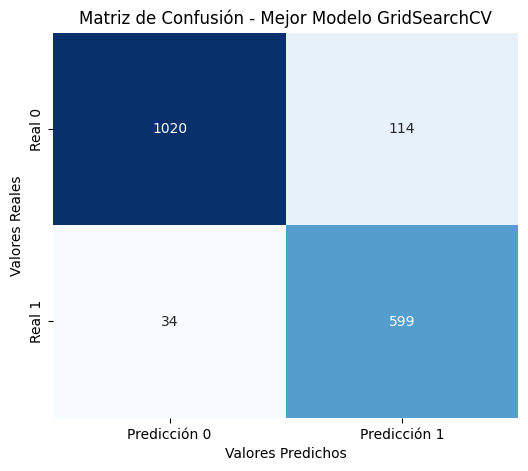

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_xgb = grid_xgb.best_estimator_
y_pred_xgb_best = best_xgb.predict(X_test)

cm_best = confusion_matrix(y_test, y_pred_xgb_best)
print("\nMatriz de Confusión (Mejor Modelo GridSearchCV):\n")
print(cm_best)


plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicción 0', 'Predicción 1'], yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de Confusión - Mejor Modelo GridSearchCV')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

In [ ]:
import pandas as pd

df_comp_xgb = pd.DataFrame({
    "Modelo": ["XGBoost base", "XGBoost GridSearch"],
    "F1_test": [f1_xgb_base, f1_xgb_best]
})

df_comp_xgb


,Modelo,F1_test
0,XGBoost base,0.883408
1,XGBoost GridSearch,0.890045


# Regresión logistica

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros (Regresión Logística):
{'C': 10, 'class_weight': None, 'penalty': 'l1'}
F1 promedio CV: 0.8788

Regresión Logística optimizada (GridSearch)
              precision    recall  f1-score   support

      Negada       0.96      0.90      0.93      1134
    Aprobada       0.84      0.93      0.88       633

    accuracy                           0.91      1767
   macro avg       0.90      0.92      0.91      1767
weighted avg       0.92      0.91      0.91      1767

F1-Score test optimizado: 0.883


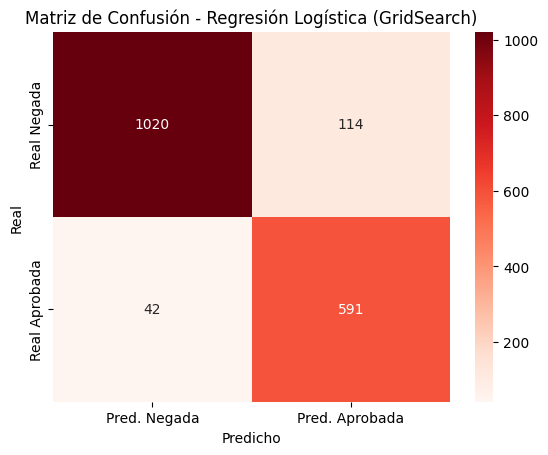

In [ ]:
# 2. Regresión Logística con GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Modelo base para el grid
log_reg_base = LogisticRegression(
    max_iter=1000,
    solver="liblinear"   # permite L1 y L2
)

# Espacio de búsqueda de hiperparámetros
param_grid_log = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

cv_log = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_log = GridSearchCV(
    estimator=log_reg_base,
    param_grid=param_grid_log,
    scoring="f1",
    cv=cv_log,
    n_jobs=-1,
    verbose=1
)

# Búsqueda
grid_log.fit(X_train, y_train)

print("Mejores parámetros (Regresión Logística):")
print(grid_log.best_params_)
print(f"F1 promedio CV: {grid_log.best_score_:.4f}")

# Mejor modelo
best_log_reg = grid_log.best_estimator_

# Predicciones en test
y_pred_log_best = best_log_reg.predict(X_test)

print("\nRegresión Logística optimizada (GridSearch)")
print(classification_report(y_test, y_pred_log_best, target_names=["Negada", "Aprobada"]))

f1_log_best = f1_score(y_test, y_pred_log_best)
print(f"F1-Score test optimizado: {f1_log_best:.3f}")

# Matriz de confusión
cm_log_best = confusion_matrix(y_test, y_pred_log_best)
sns.heatmap(cm_log_best, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Pred. Negada", "Pred. Aprobada"],
            yticklabels=["Real Negada", "Real Aprobada"])
plt.title("Matriz de Confusión - Regresión Logística (GridSearch)")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.show()


In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, classification_report
)
import numpy as np

# Predicciones
y_pred = best_log_reg.predict(X_test)
y_prob = best_log_reg.predict_proba(X_test)[:, 1]  # probabilidades clase positiva

# Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Métricas del Modelo: Regresión Logística Optimizada ===")
print(f"Precisión:      {precision:.6f}")
print(f"Recall:         {recall:.6f}")
print(f"F1-Score:       {f1:.6f}")
print(f"Accuracy:       {accuracy:.6f}")
print(f"ROC-AUC:        {roc_auc:.6f}")



=== Métricas del Modelo: Regresión Logística Optimizada ===
Precisión:      0.838298
Recall:         0.933649
F1-Score:       0.883408
Accuracy:       0.911715
ROC-AUC:        0.960517


# Comparación general de modelos con GridSearch

Se consolidan las métricas de todos los modelos (Precisión, Recall, F1 y Accuracy) optimizadas con GridSearch para identificar cuál presenta mejor desempeño en la clasificación binaria del resultado final.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
modelos = {
    "DT base": dt,                      # Árbol original
    "DT tunado": grid_dt.best_estimator_,
    "RF base": rf,                      # Random Forest original
    "RF tunado": grid_rf.best_estimator_,
    "XGB base": xgb,                    # XGBoost original
    "XGB tunado": grid_xgb.best_estimator_
}

In [ ]:
filas = []
for nombre, modelo in modelos.items():
    # predicciones duras (0/1)
    y_pred = modelo.predict(X_test)

    # probabilidades para calcular AUC (si el modelo las tiene)
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    filas.append({
        "Modelo": nombre,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3),
        "ROC-AUC": round(auc, 3) if auc is not None else None
    })

resumen_modelos = pd.DataFrame(filas).sort_values("F1-Score", ascending=False).reset_index(drop=True)

resumen_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGB tunado,0.916,0.840,0.946,0.890,0.967
1,RF tunado,0.912,0.834,0.943,0.885,0.964
2,DT tunado,0.911,0.828,0.948,0.884,0.956
3,XGB base,0.912,0.857,0.905,0.880,0.962
4,RF base,0.898,0.826,0.907,0.864,0.930
5,DT base,0.876,0.828,0.826,0.827,0.865


# Curvas de ROC

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
y_proba_dt  = best_dt.predict_proba(X_test)[:, 1]
y_proba_rf  = best_rf.predict_proba(X_test)[:, 1]
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]



In [ ]:
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

In [ ]:
auc_dt  = auc(fpr_dt, tpr_dt)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

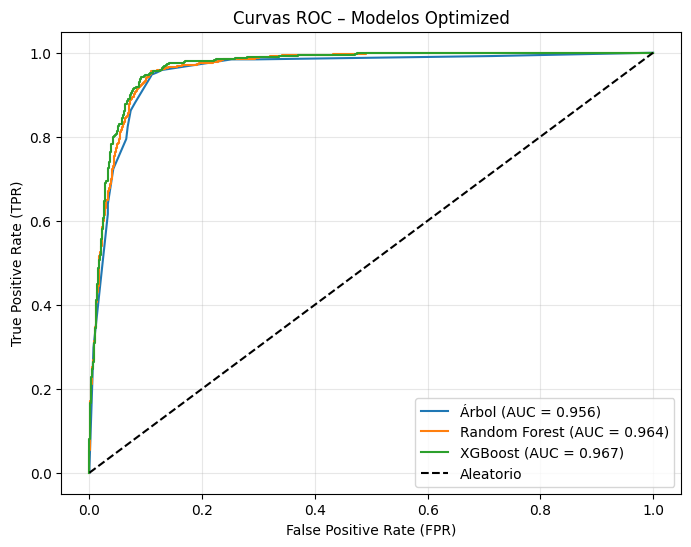

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr_dt,  tpr_dt,  label=f"Árbol (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], "k--", label="Aleatorio")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curvas ROC – Modelos Optimized")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La comparación mediante la curva ROC se realizó con los modelos optimizados mediante GridSearch, garantizando una evaluación homogénea y consistente entre los modelos

# Optimizacion de XGBooots con Optuna

In [ ]:
!pip install optuna

import optuna
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 9.5 MB/s eta 0:00:00


In [ ]:

def objetivo(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, ratio),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1 = cross_val_score(model, X_train, y_train, scoring="f1", cv=cv, n_jobs=-1).mean()

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objetivo, n_trials=40, show_progress_bar=True)




[I 2025-11-21 01:44:35,584] A new study created in memory with name: no-name-b39b4fc2-fb81-4ff1-a97e-692151bb28aa


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-21 01:44:39,359] Trial 0 finished with value: 0.8782632180199765 and parameters: {'n_estimators': 319, 'max_depth': 9, 'learning_rate': 0.17755306390784936, 'subsample': 0.857016594456216, 'colsample_bytree': 0.8659531704550342, 'gamma': 3.5978651252172207, 'min_child_weight': 3, 'scale_pos_weight': 1.5395381931934433}. Best is trial 0 with value: 0.8782632180199765.
[I 2025-11-21 01:44:46,126] Trial 1 finished with value: 0.8788721717836816 and parameters: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.22941951934125454, 'subsample': 0.7113907917956795, 'colsample_bytree': 0.6000281661309463, 'gamma': 4.21806037117079, 'min_child_weight': 4, 'scale_pos_weight': 1.501209710329285}. Best is trial 1 with value: 0.8788721717836816.
[I 2025-11-21 01:44:57,825] Trial 2 finished with value: 0.8728951808898247 and parameters: {'n_estimators': 824, 'max_depth': 6, 'learning_rate': 0.27556181227291676, 'subsample': 0.6441057108282182, 'colsample_bytree': 0.7333852662167061,

In [ ]:
print("Mejores parámetros:")
print(study.best_params)

print("\nMejor F1 obtenido:")
print(study.best_value)

Mejores parámetros:
{'n_estimators': 698, 'max_depth': 3, 'learning_rate': 0.04861371327268598, 'subsample': 0.68844724811973, 'colsample_bytree': 0.7226227410556779, 'gamma': 0.05298534144116629, 'min_child_weight': 3, 'scale_pos_weight': 1.4551429725626102}

Mejor F1 obtenido:
0.882092617965095


In [ ]:
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


best_params = study.best_params.copy()
best_params.update({
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "use_label_encoder": False
})

xgb_opt = XGBClassifier(**best_params)
xgb_opt.fit(X_train, y_train)

y_pred_opt = xgb_opt.predict(X_test)
f1_opt = f1_score(y_test, y_pred_opt)
print(f"F1-Score XGBoost (Optuna): {f1_opt:.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:47:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-Score XGBoost (Optuna): 0.889


# Resultados finales y selección del mejor modelo

Se presentan los mejores modelos según F1-score, se analizan las mejoras logradas con la optimización y se selecciona el modelo más adecuado para la siguiente etapa del proyecto.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

def evaluar_modelo(nombre, modelo, X_test, y_test):

    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc = np.nan

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc
    }


In [ ]:
resultados = []

resultados.append(evaluar_modelo("DT base", dt, X_test, y_test))
resultados.append(evaluar_modelo("DT + SMOTE", dt_smote, X_test, y_test))

resultados.append(evaluar_modelo("DT (GridSearch)", best_dt, X_test, y_test))

resultados.append(evaluar_modelo("RF base", rf, X_test, y_test))
resultados.append(evaluar_modelo("RF (GridSearch)", best_rf, X_test, y_test))

resultados.append(evaluar_modelo("XGB base", xgb, X_test, y_test))
resultados.append(evaluar_modelo("XGB (GridSearch)",grid_xgb.best_estimator_, X_test, y_test))

resultados.append(evaluar_modelo("XGB (Optuna)", xgb_opt, X_test, y_test))

df_modelos = pd.DataFrame(resultados)
df_modelos = df_modelos.sort_values(by="F1", ascending=False).reset_index(drop=True)

print("Comparación final de modelos (ordenados por F1):")
display(df_modelos)



Comparación final de modelos (ordenados por F1):


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGB (GridSearch),0.916242,0.840112,0.946288,0.890045,0.966926
1,XGB (Optuna),0.916808,0.852174,0.928910,0.888889,0.966326
2,RF (GridSearch),0.912281,0.833799,0.943128,0.885100,0.963891
3,DT (GridSearch),0.910583,0.827586,0.947867,0.883652,0.955514
4,XGB base,0.911715,0.856502,0.905213,0.880184,0.962193
5,RF base,0.898132,0.825899,0.906793,0.864458,0.929735
6,DT base,0.876061,0.827532,0.826224,0.826877,0.865052
7,DT + SMOTE,0.863611,0.796970,0.830964,0.813612,0.856399


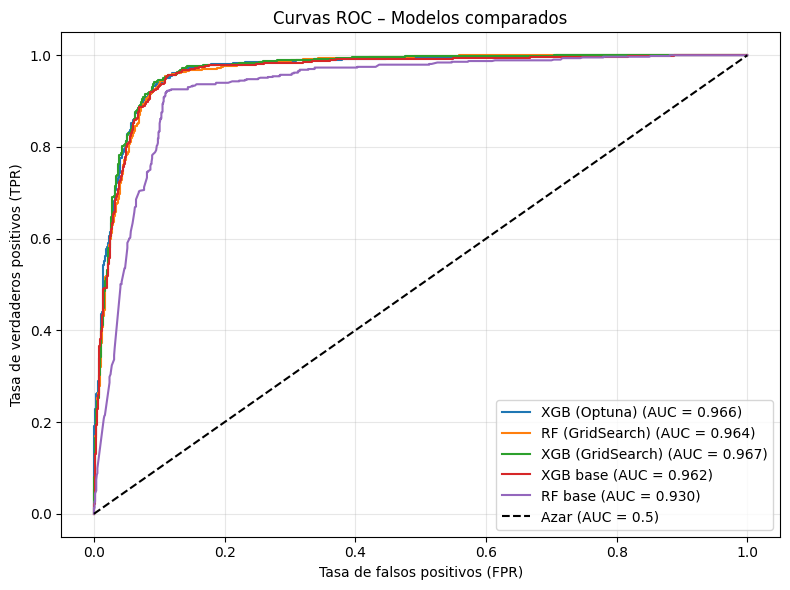

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Diccionario de modelos a comparar
modelos_roc = {
    "XGB (Optuna)": xgb_opt,
    "RF (GridSearch)": best_rf,
    "XGB (GridSearch)": grid_xgb,
    "XGB base": xgb,
    "RF base": rf
}

plt.figure(figsize=(8, 6))

resultados_auc = []

for nombre, modelo in modelos_roc.items():
    # Probabilidad de clase positiva
    y_proba = modelo.predict_proba(X_test)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    resultados_auc.append((nombre, auc))

    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})")

# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")

plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC – Modelos comparados")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df_auc = pd.DataFrame(resultados_auc, columns=["Modelo", "AUC"])
df_auc = df_auc.sort_values(by="AUC", ascending=False).reset_index(drop=True)

print("Resumen AUC por modelo:")
display(df_auc)


Resumen AUC por modelo:


,Modelo,AUC
0,XGB (GridSearch),0.966926
1,XGB (Optuna),0.966326
2,RF (GridSearch),0.963891
3,XGB base,0.962193
4,RF base,0.929735


El mejor modelo y el seleccionado es **XGBoost** optimizado con GridSearch basado en el F1 - Score

# SHAP

Se aplica SHAP para interpretar el modelo con mejor desempeño y comprender el aporte individual de cada variable en la predicción. Este análisis permite visualizar cómo influyen las características socioeconómicas, académicas y demográficas en la clasificación Aprobada/Negada, identificando variables con efectos positivos o negativos sobre la probabilidad de aprobación. Los gráficos SHAP summary plot y force plot facilitan una lectura transparente del comportamiento del modelo y refuerzan la interpretación ética y técnica del proceso

# XGBoots optimizado con GridSearch

In [ ]:
import shap
shap.initjs()


In [ ]:
X_test_array = X_test.copy()

explainer_xgb = shap.TreeExplainer(grid_xgb.best_estimator_)
shap_values_xgb = explainer_xgb.shap_values(X_test_array)


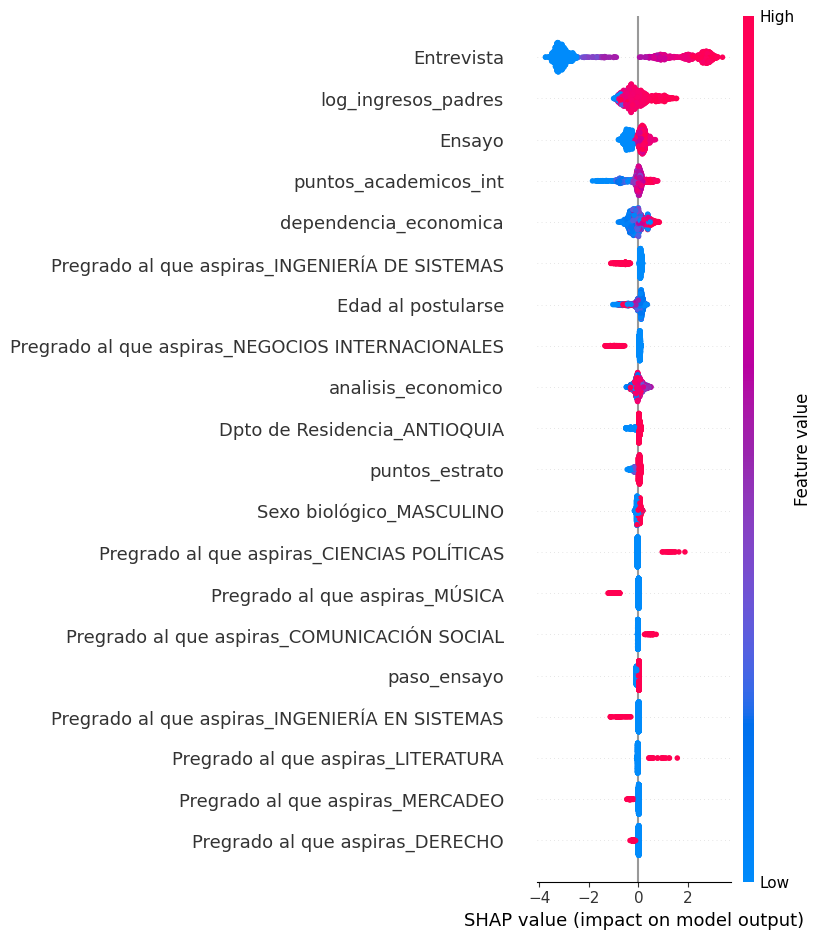

In [ ]:
shap.summary_plot(shap_values_xgb, X_test_array, plot_type="dot")


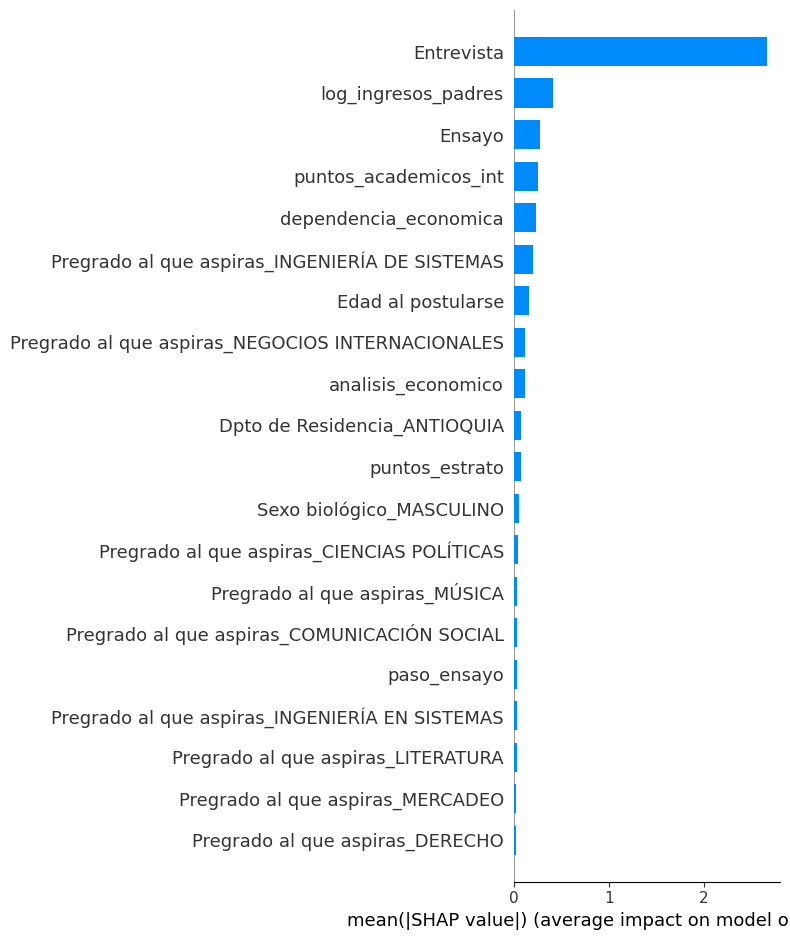

In [ ]:
shap.summary_plot(shap_values_xgb, X_test_array, plot_type="bar")


In [ ]:
import joblib

# 1. Elegimos nuestro mejor modelo según df_modelos (ajusta el nombre si es otro)
best_matric_model = xgb_opt

# 2. Guardamos también la lista de columnas usadas en X_train (dummies)
matric_package = {
    "model": best_matric_model,
    "columns": X_train.columns.tolist()
}

# 3. Guardamos el paquete en un .joblib
joblib.dump(matric_package, "/content/modelo_clf_aprobacion.joblib")

print("Modelo de matriculado/no matriculado guardado como modelo_clf_matricula.joblib")


Modelo de matriculado/no matriculado guardado como modelo_clf_matricula.joblib
